**Tarea 6**

Importar librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
from GeneticAlgorithm import *

Problema 1(a)

Converged at generation 102
Optimal x = 0.851189793401069
Maximum f(x) = 1.8505952429626031


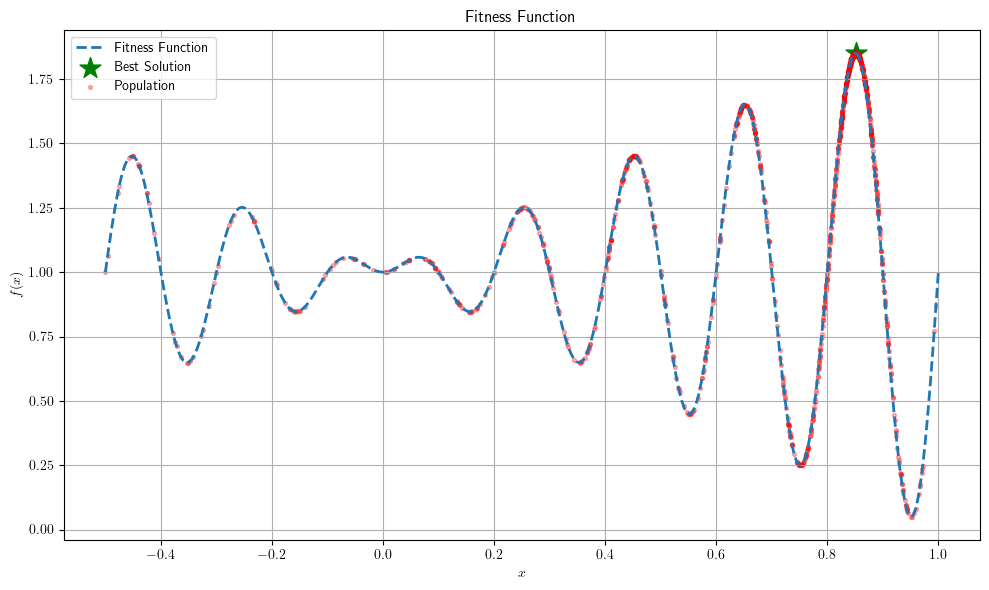

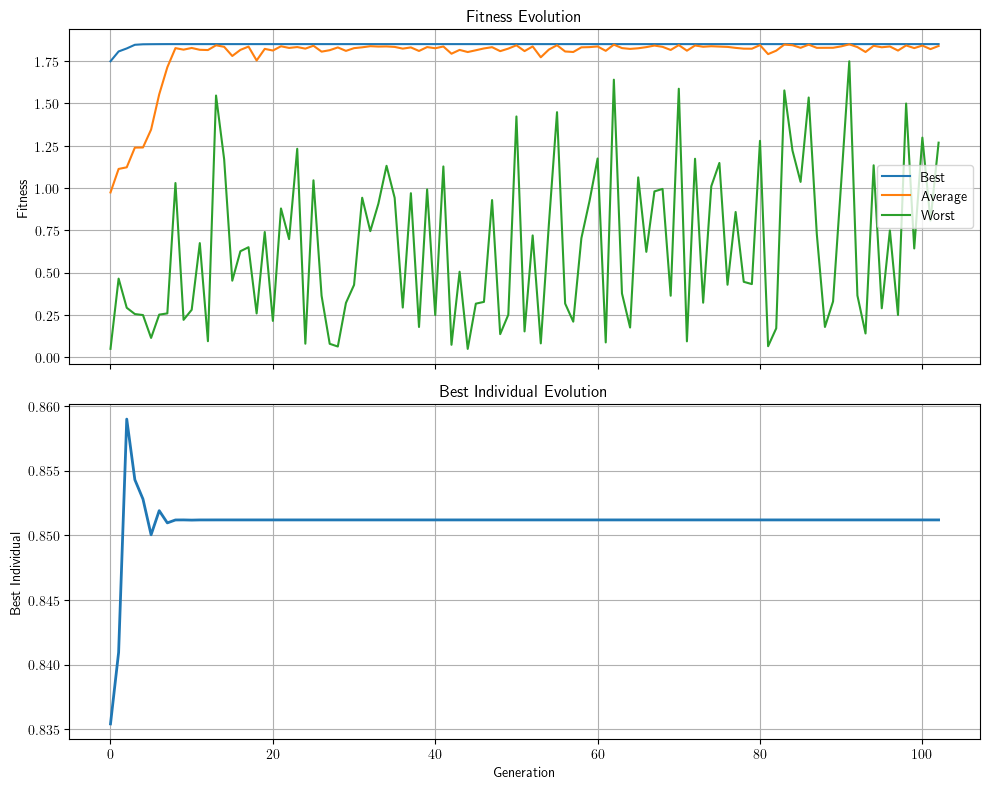

In [46]:
def fitness_function(individual):
    x = individual[0]

    return x*np.sin(10*np.pi*x) + 1

ga = GeneticAlgorithm(
    fitness_function=fitness_function,
    num_traits=1,
    low_trait=[-0.5],
    high_trait=[1.0],
    pop_size=100,
    mutation_prob=0.05,
    crossover_prob=0.8,
    elitism=True,
    delta=100,
    epsilon=0.01,
    max_generations=200,
    seed=0
)

result = ga.optimize()

print("Optimal x =", result["best_individual"][0])
print("Maximum f(x) =", result["best_fitness"])

ga.plot_results(filename=["punto_1a_contour_fitness","punto_1a_fitness_evolution"],save=True)

Punto 1(b)

Converged at generation 100
Optimal x = -1.9999999984711223
Maximum f(x) = 1.0


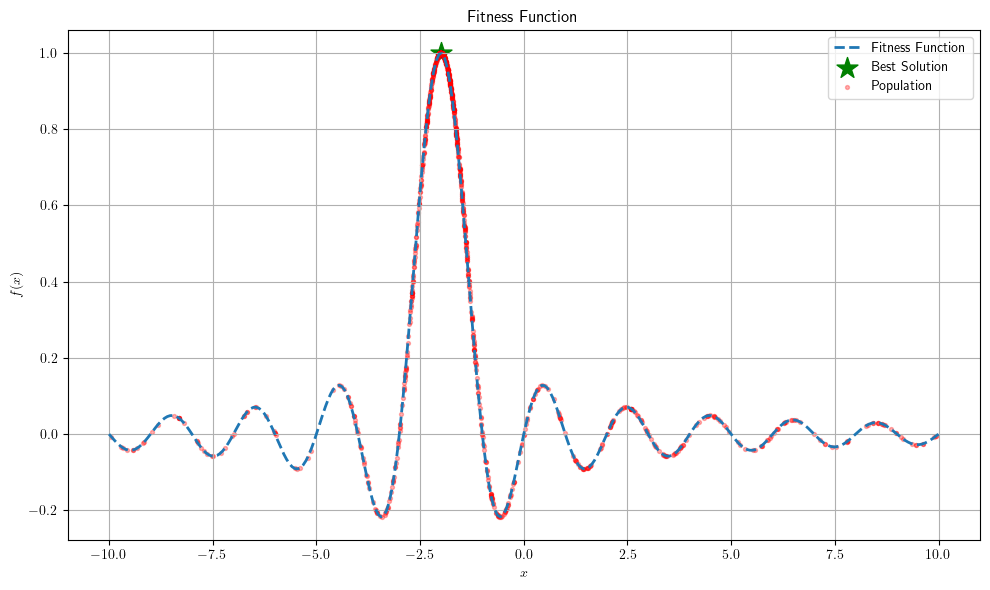

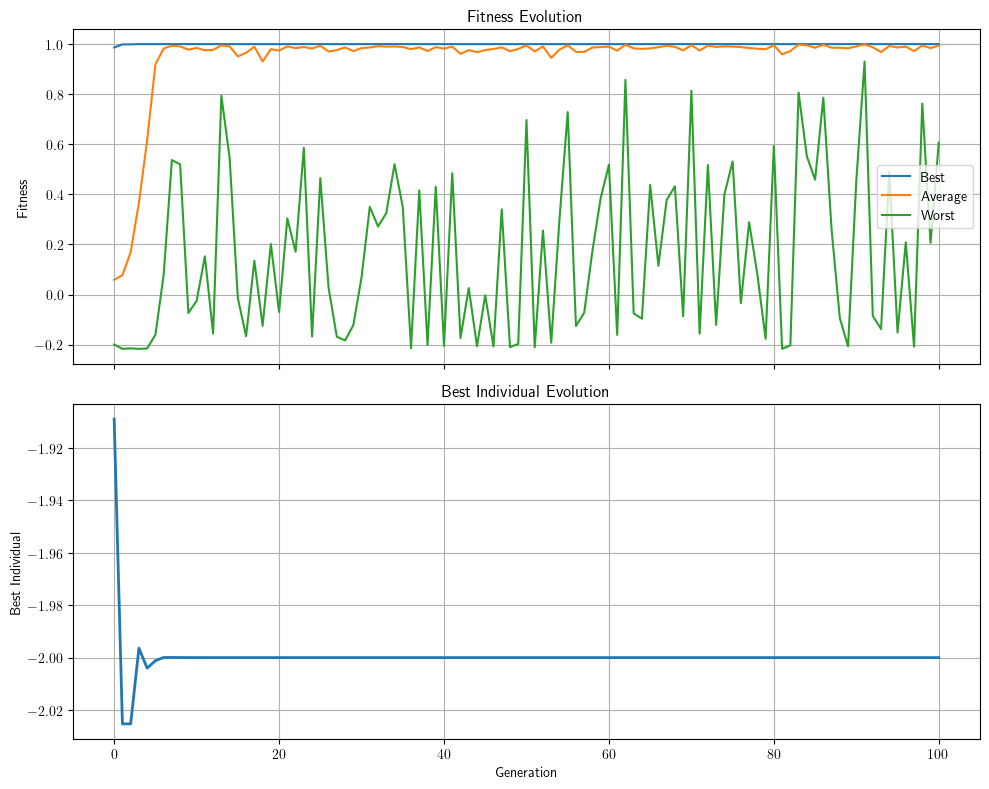

In [3]:
def fitness_function(individual):
    x = individual[0]

    return np.sinc(x+2)

ga = GeneticAlgorithm(
    fitness_function=fitness_function,
    num_traits=1,
    low_trait=[-10],
    high_trait=[10],
    pop_size=100,
    mutation_prob=0.05,
    crossover_prob=0.8,
    elitism=True,
    delta=100,
    epsilon=0.01,
    max_generations=200,
    seed=0
)

result = ga.optimize()

print("Optimal x =", result["best_individual"][0])
print("Maximum f(x) =", result["best_fitness"])

ga.plot_results(filename=["punto_1b_contour_fitness","punto_1b_fitness_evolution"],save=True)

Punto 1(c)

Converged at generation 104
Best Individual:
[0.70710699 0.99034411]
Best Fitness:
0.430650219139771


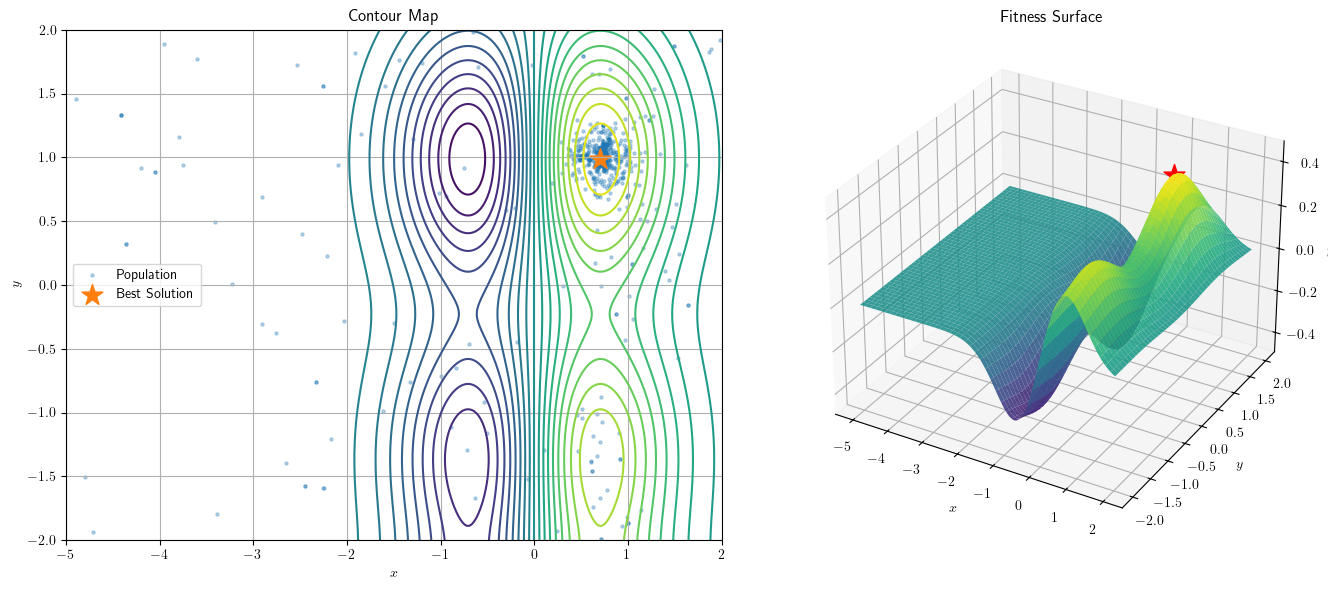

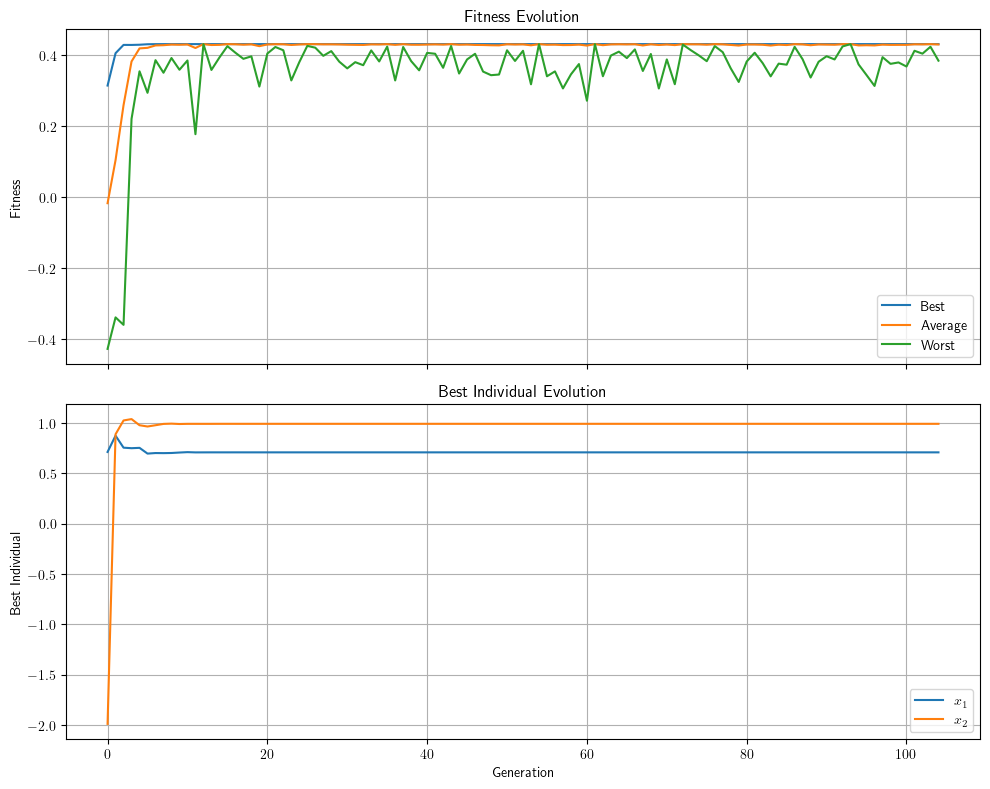

In [4]:
def fitness_function(X):
    x = X[0]
    y = X[1]
    z = (0.8*x*np.exp(-(x**2)-(y+1.3)**2) + x*np.exp(-(x**2)-(y-1)**2) + 1.15*x*np.exp(-(x**2)-(y+3.25)**2))
    return z 

ga = GeneticAlgorithm(
    fitness_function=fitness_function,
    num_traits=2,
    low_trait=[-5, -2],
    high_trait=[2, 2],
    pop_size=50,
    mutation_prob=0.05,
    crossover_prob=0.8,
    elitism=True,
    max_generations=200,
    delta=100,
    epsilon=0.001,
    seed=0,
)

result = ga.optimize()

print("Best Individual:")
print(result["best_individual"])

print("Best Fitness:")
print(result["best_fitness"])

ga.plot_results(filename=["punto_1c_contour_fitness","punto_1c_fitness_evolution"],save=True)

Punto 1(d)

Converged at generation 108
Best Individual:
[-8.01888169  0.0188817 ]
Best Fitness:
7.002951453856155


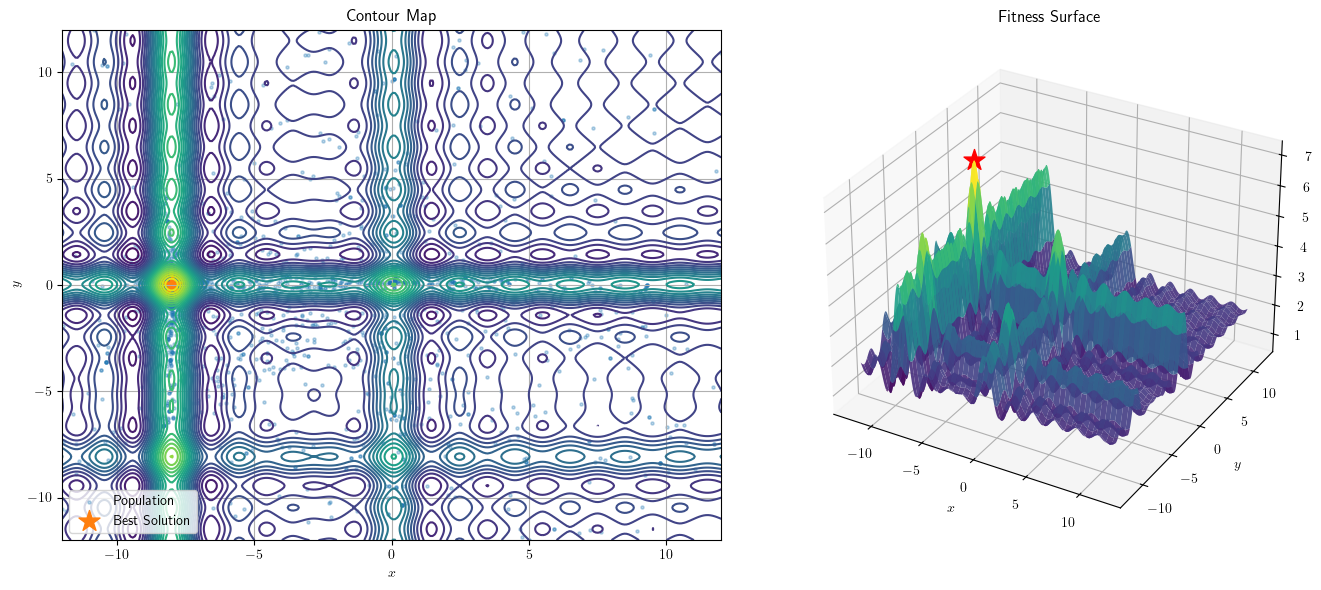

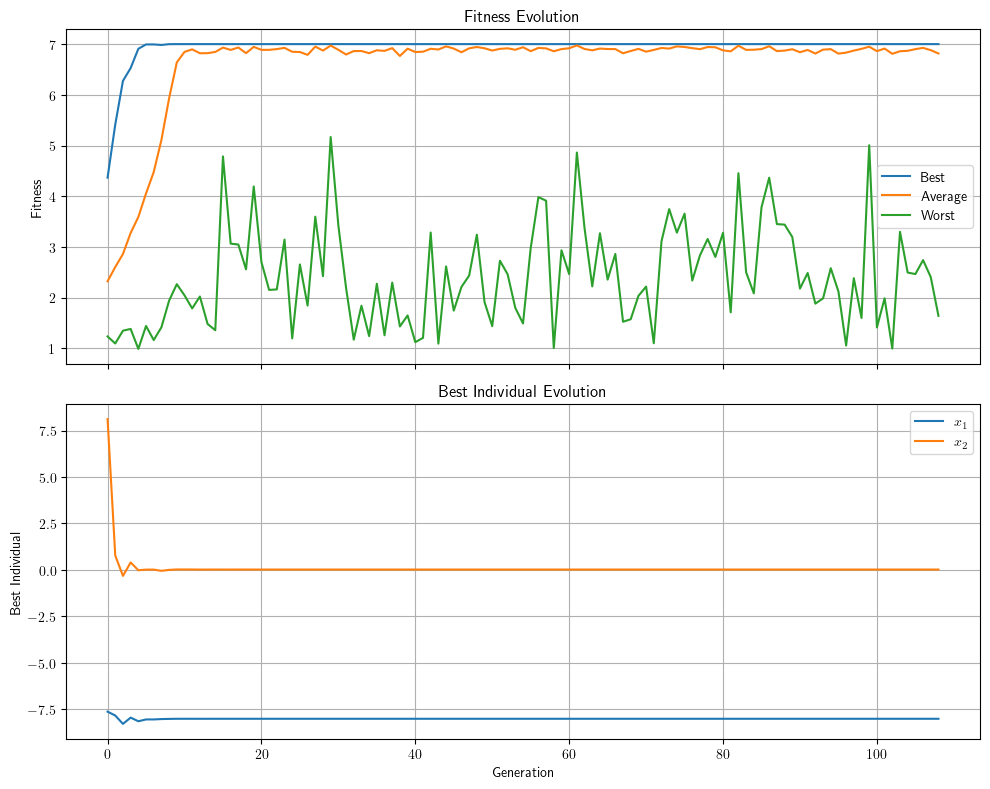

In [7]:
def fitness_function(X):
    x = X[0]
    y = X[1]
    z = (1.5*np.sinc(x)+2*np.sinc(y)+3*np.sinc(x+8)+np.sinc(y+8)+2)
    return z 

ga = GeneticAlgorithm(
    fitness_function=fitness_function,
    num_traits=2,
    low_trait=[-12, -12],
    high_trait=[12, 12],
    pop_size=200,
    mutation_prob=0.05,
    crossover_prob=0.8,
    elitism=True,
    max_generations=500,
    delta=100,
    epsilon=0.001,
    seed=5,
)

result = ga.optimize()

print("Best Individual:")
print(result["best_individual"])

print("Best Fitness:")
print(result["best_fitness"])

ga.plot_results(filename=["punto_1d_contour_fitness_2","punto_1d_fitness_evolution_2"],save=True)

Punto 2

Importar datos de elevación, definir función de interpolación y función de fitness

In [2]:
from scipy.io import loadmat
import numpy as np
from scipy.interpolate import RegularGridInterpolator

data = loadmat("colom.mat")
colom = data["colom"]
colom_flip = np.flipud(colom)
northlat = 13
southlat = -5
westlong = -84
eastlong = -64

longitudes = np.linspace(westlong,eastlong,colom.shape[1])
latitudes = np.linspace(southlat,northlat,colom.shape[0])

elevation_interp = RegularGridInterpolator((latitudes, longitudes),colom,method='linear',bounds_error=False,fill_value=-1000)

def elevation_fitness(individual):
    lon = individual[0]
    lat = individual[1]
    h = elevation_interp([[lat, lon]])[0]
    return h


Optimización para buscar el punto más alto

In [3]:
ga = GeneticAlgorithm(
    fitness_function=elevation_fitness,
    num_traits=2,
    low_trait=[-84, -5],
    high_trait=[-64, 13],
    pop_size=500,
    mutation_prob=0.4,
    crossover_prob=0.8,
    elitism=True,
    max_generations=1000,
    delta=100,
    epsilon=0.01,
    seed=2
)

result = ga.optimize()

best_long = result["best_individual"][0]
best_lat = result["best_individual"][1]

best_elev = result["best_fitness"]

print("Longitude =", best_long)
print("Latitude  =", best_lat)
print("Elevation =", best_elev, "m")

Converged at generation 604
Longitude = -72.25000001239502
Latitude  = 6.416666665484043
Elevation = 4569.999806687025 m


Gráfica del Mapa de Colombia y Evolución de GA

C:\Users\MATEO\AppData\Local\Temp\ipykernel_21612\3132479618.py:51: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\MATEO\AppData\Local\Temp\ipykernel_21612\3132479618.py:53: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig1.savefig(f"{filename[0]}.pdf", dpi=500, bbox_inches='tight')
C:\Users\MATEO\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


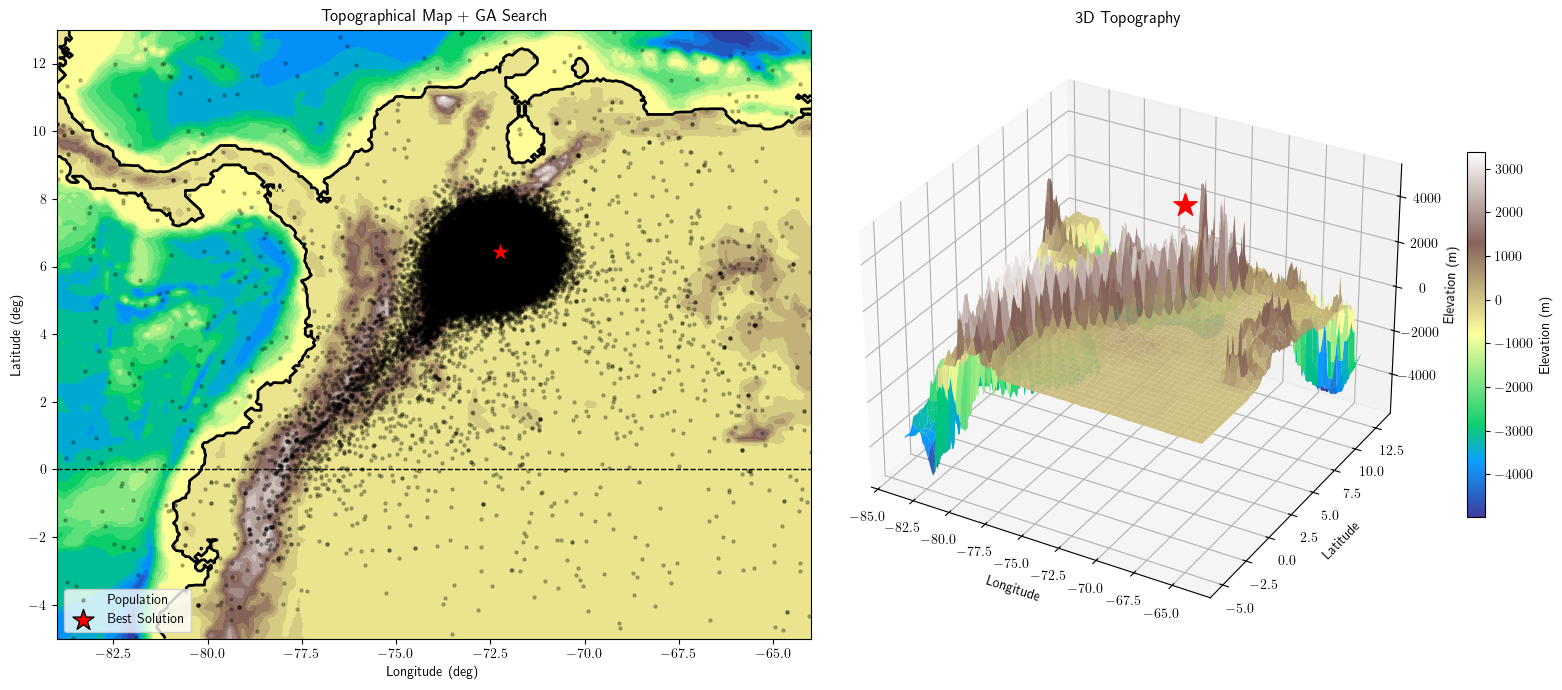

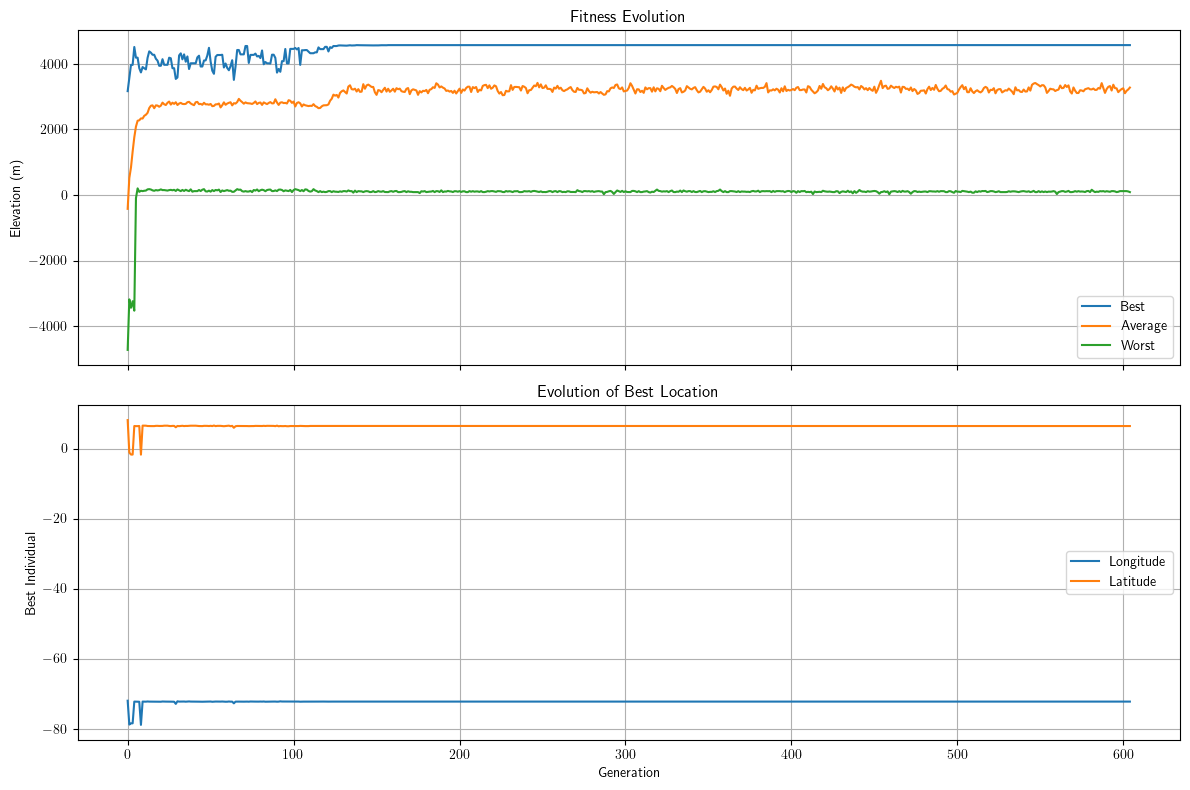

In [4]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt


def plot_colombia_results(aga,colom,longitudes,latitudes,best_long,best_lat,filename=None,save=True):
    """
    Visualization for the Colombia topography optimization problem.
    """

    # ==========================================================
    # FIGURE 1
    # ==========================================================

    fig1 = plt.figure(figsize=(16, 7))

    # ----------------------------------------------------------
    # CONTOUR MAP
    # ----------------------------------------------------------

    ax1 = fig1.add_subplot(121)
    ax1.contourf(longitudes,latitudes,colom,levels=30,cmap='terrain')
    # shoreline
    ax1.contour(longitudes,latitudes,colom,levels=[0],colors='black',linewidths=2    )

    # equator
    ax1.axhline(y=0,color='k',linestyle='--',linewidth=1)
    # all population members
    all_points = np.vstack(aga.population_history)
    ax1.scatter(all_points[:, 0],all_points[:, 1],s=5,c='k',alpha=0.25,label='Population')
    ax1.scatter(best_long,best_lat,marker='*',s=250,c='red',edgecolors='black',linewidths=1,label='Best Solution')
    ax1.set_xlabel('Longitude (deg)')
    ax1.set_ylabel('Latitude (deg)')
    ax1.set_title('Topographical Map + GA Search')
    ax1.legend()

    # ----------------------------------------------------------
    # 3D SURFACE
    # ----------------------------------------------------------

    ax2 = fig1.add_subplot(122,projection='3d')
    LON, LAT = np.meshgrid(longitudes,latitudes)
    surf = ax2.plot_surface(LON,LAT,colom,cmap='terrain',linewidth=0,antialiased=True,alpha=0.95)
    best_elev = np.max(aga.best_fitness_history)
    ax2.scatter(best_long, best_lat,best_elev,color='red', marker='*',s=300)
    ax2.set_xlabel('Longitude')
    ax2.set_ylabel('Latitude')
    ax2.set_zlabel('Elevation (m)')
    ax2.set_title('3D Topography')
    fig1.colorbar(surf,ax=ax2,shrink=0.6,label='Elevation (m)')
    plt.tight_layout()
    if save:
        fig1.savefig(f"{filename[0]}.pdf", dpi=500, bbox_inches='tight')
    plt.show()

    # ==========================================================
    # FIGURE 2
    # ==========================================================

    fig2, axs = plt.subplots(2,1,figsize=(12, 8),sharex=True)
    generations = np.arange(len(aga.best_fitness_history))
    # ----------------------------------------------------------
    # FITNESS EVOLUTION
    # ----------------------------------------------------------
    axs[0].plot(generations,aga.best_fitness_history,label='Best')
    axs[0].plot(generations,aga.avg_fitness_history,label='Average')
    axs[0].plot(generations,aga.worst_fitness_history,label='Worst')
    axs[0].set_ylabel('Elevation (m)')
    axs[0].set_title('Fitness Evolution')
    axs[0].grid(True)
    axs[0].legend()

    # ----------------------------------------------------------
    # BEST INDIVIDUAL EVOLUTION
    # ----------------------------------------------------------

    best_hist = np.array(aga.best_individual_history)
    axs[1].plot(generations,best_hist[:, 0],label='Longitude')
    axs[1].plot(generations,best_hist[:, 1],label='Latitude')
    axs[1].set_xlabel('Generation')
    axs[1].set_ylabel('Best Individual')
    axs[1].set_title('Evolution of Best Location')
    axs[1].grid(True)
    axs[1].legend()

    plt.tight_layout()
    if save:
        fig2.savefig(f"{filename[1]}.pdf", dpi=500, bbox_inches='tight')
    plt.show()

plot_colombia_results(ga,colom,longitudes,latitudes,best_long,best_lat,
                      filename=["colombia_1_contour_fitness_1","colombia_1_fitness_evolution_1"],
                      save=True)


Realizando el proceso para varios seeds:

In [ ]:
results = []

for seed in range(10):

    ga = GeneticAlgorithm(
        fitness_function=elevation_fitness,
        num_traits=2,
        low_trait=[-84,-5],
        high_trait=[-64,13],
        pop_size=800,
        mutation_prob=0.5,
        crossover_prob=0.8,
        elitism=True,
        max_generations=1000,
        seed=seed
    )

    result = ga.optimize()

    results.append(result["best_fitness"])

    print(seed,result["best_individual"], result["best_fitness"])

print("Max: ",np.max(results))
print("Mean: ",np.mean(results))
print("STD: ",np.std(results))

